In [1]:
data_path = r"C:\\Users\\Pascal Marijan\\OneDrive - dfki.de\Dokumente\\Veröffentlichungen\\Model comparison\\Data\\stationary_operation_point_means_2022-01-01_2024-01-01.csv"

In [92]:
import pandas as pd
from window_generator import DataLoaderCsv

data_loader = DataLoaderCsv()
raw_data = data_loader.get_data(data_path)
raw_data = raw_data.loc[:, ~raw_data.columns.str.contains('^Unnamed')]
raw_data.dropna(how="all", axis=1, inplace=True)
raw_data.loc[:, raw_data.columns.str.contains('time')] = raw_data.loc[:, raw_data.columns.str.contains('time')].apply(pd.to_datetime)

In [93]:
data = raw_data.copy()

In [94]:
data["cluster"]

KeyError: 'cluster'

In [4]:
data["spec_energy"] = (data["A56-MD01.JZ01"] + data["A56-FN02.JZ01"] + data["A56-SR01.JZ01"]) / data["A51-WF01.FC01"]
data['center_time'] = data['start_time'] + (data['end_time'] - data['start_time'])/2

Main drive speed setpoint - A56-MD01.SC02 <br>
Main fan speed setpoint - A56-FN02.SC02 <br>
Classifier speed setpoint - A56-SR01.SC02 <br>
Tension pressure setpoint - A56-HS01.PS01 <br>
Feed setpoint - A51-WF01.FS01 <br>

In [5]:
setpoint_columns = ["A51-WF01.FS01", "A56-MD01.SC02", "A56-FN02.SC02", "A56-SR01.SC02", "A56-HS01.PS01"]

In [6]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
normalized_data = pd.DataFrame(scaler.fit_transform(data.loc[:, setpoint_columns]), columns=setpoint_columns)
normalized_data['center_time'] = data['center_time']

Create confidence intervals

In [7]:
rolling = normalized_data.rolling(window=25, step=25, center=True)
confidence_intervals = rolling.agg({col: ['mean', 'std'] for col in setpoint_columns}).iloc[1:]
confidence_intervals['center_time'] = normalized_data['center_time'].iloc[25::25]
confidence_intervals.set_index('center_time', inplace=True, drop=True)

for column in setpoint_columns:
    confidence_intervals[f'{column}_ci_lower'] = confidence_intervals[(column, 'mean')] - 1.96 * confidence_intervals[(column, 'std')] / (10 ** 0.5)
    confidence_intervals[f'{column}_ci_upper'] = confidence_intervals[(column, 'mean')] + 1.96 * confidence_intervals[(column, 'std')] / (10 ** 0.5)

c:\git\gpai_theodor\venv_tf_nude\Lib\site-packages\pandas\core\indexes\base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


In [8]:
center_rows = data.loc[data['center_time'].isin(confidence_intervals.index)]

Calculate setpoint clusters

In [9]:
import numpy as np
from sklearn.cluster import KMeans

setpoint_data = data[setpoint_columns]
setpoint_data_sorted = setpoint_data.sort_values(by='A51-WF01.FS01')
k = 100
indices = np.linspace(0, len(setpoint_data_sorted) - 1, k, dtype=int)
start_centroids = setpoint_data_sorted.iloc[indices]
kmeans = KMeans(n_clusters=k, init=start_centroids, n_init=1)
kmeans.fit(setpoint_data)

ordered_clusters = pd.DataFrame(kmeans.cluster_centers_, columns=setpoint_columns).sort_values(by=setpoint_columns).reset_index(names='old_cluster').reset_index(names='new_cluster')
cluster_mapping = ordered_clusters.set_index('old_cluster')['new_cluster'].to_dict()
data['cluster'] = pd.Series(kmeans.labels_).map(cluster_mapping)

Calculate calculation error

In [72]:
import os
import mlflow

os.environ["MLFLOW_TRACKING_URI"] = "http://mlflow.gppro.app/"
os.environ["MLFLOW_TRACKING_INSECURE_TLS"] = "true"
os.environ["MLFLOW_TRACKING_USERNAME"] = "mlflow_user"
os.environ["MLFLOW_TRACKING_PASSWORD"] = "5T17AHb22tLg"

# run_id = 'a363c822a45f4a828efe30a64a125753'
# model_uri = f"runs:/{run_id}/model"

model_name = "3-process_optimize-model-total_spec_energy"
version = 8
model_uri = f"models:/{model_name}/{version if version else 'production'}"

model = mlflow.tensorflow.load_model(model_uri=model_uri)

run_id = mlflow.models.get_model_info(model_uri).run_id
run = mlflow.get_run(run_id)
config_json = mlflow.artifacts.load_dict(run.info.artifact_uri + f"/{model_name.split('-')[-1]}.json")

c:\git\gpai_theodor\venv_tf_nude\Lib\site-packages\urllib3\connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'mlflow.gppro.app'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
c:\git\gpai_theodor\venv_tf_nude\Lib\site-packages\urllib3\connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'mlflow.gppro.app'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
c:\git\gpai_theodor\venv_tf_nude\Lib\site-packages\urllib3\connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'mlflow.gppro.app'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
c:\git\gpai_theodor\venv_tf_nud

In [ ]:
from pydantic import BaseModel, Field
from gpai.process_parameter import ProcessParameter
from gpai.preprocessing import Preprocessing

class ModelConfig(BaseModel):
    features: list[ProcessParameter]
    labels: list[ProcessParameter]
    scaling_required: bool = True
    mill_model_class: str = Field(validation_alias="class", default=None)
    build_args: dict | None = None

model_config = ModelConfig(**config_json)
preprocessor = Preprocessing(model_config)

In [83]:
gpac_regex = [gpac for x in preprocessor.features for gpac in x.get_tags()]
data['A56-HS01.PZ14'] = data[['A56-HS01.PZ13', 'A56-HS01.PZ24']].mean(axis=1)
filtered_columns = [col for regex in gpac_regex for col in data.filter(regex=regex, axis=1).columns]
feature_rows = data[filtered_columns]
feature_rows.drop(columns=['A56-HS01.PZ13', 'A56-HS01.PZ24'], inplace=True)

C:\Users\Pascal Marijan\AppData\Local\Temp\ipykernel_3028\1941480418.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  feature_rows.drop(columns=['A56-HS01.PZ13', 'A56-HS01.PZ24'], inplace=True)


In [91]:
data.columns

Index(['A51-WF01.FC01', 'A51-WF01.FS01', 'A56-DA01.ZC01', 'A56-DA02.ZC01',
       'A56-FN02.JZ01', 'A56-FN02.SC01', 'A56-FN02.SC02', 'A56-HG01.XC01',
       'A56-HS01.PS01', 'A56-HS01.PZ13', 'A56-HS01.PZ24', 'A56-HS01.ZO01',
       'A56-HS01.ZO02', 'A56-HS01.ZO03', 'A56-HS01.ZO04', 'A56-MD01.JZ01',
       'A56-MD01.SC01', 'A56-MD01.SC02', 'A56-SR01.JZ01', 'A56-SR01.SC01',
       'A56-SR01.SC02', 'start_time', 'end_time', 'spec_energy', 'center_time',
       'cluster', 'A56-HS01.PZ14', 'spec_energy_pred',
       'spec_energy_pred_error'],
      dtype='object')

In [85]:
import numpy as np
for idx, row in feature_rows.iterrows():
    X: np.ndarray = np.vstack(feature_rows.loc[[idx]].to_numpy())
    X = preprocessor.scale_features(X)
    y: np.ndarray = model.predict(X)
    y_inverse: np.ndarray = preprocessor.rescale_labels(y)
    # print("pred:", y_inverse[0])
    # true_value = data['spec_energy'].iloc[idx]
    # print("true :", true_value)
    # print("error:", y_inverse[0] - true_value)
    # print("-" * 20)
    data.loc[idx, 'spec_energy_pred'] = y_inverse[0]

ValueError: Features  shape[-1]  is 12 must be of shape 15

In [58]:
data['spec_energy_pred_error'] = data['spec_energy'] - data['spec_energy_pred']
prediction_rows = data[(data['spec_energy_pred_error'] <= 20) & (data['spec_energy_pred_error'] > -20)]

In [59]:
from matplotlib import pyplot as plt
plt.rcParams["font.family"] = 'sans-serif'
plt.rcParams["font.sans-serif"] = 'Calibri'
plt.rcParams["font.size"] = 16

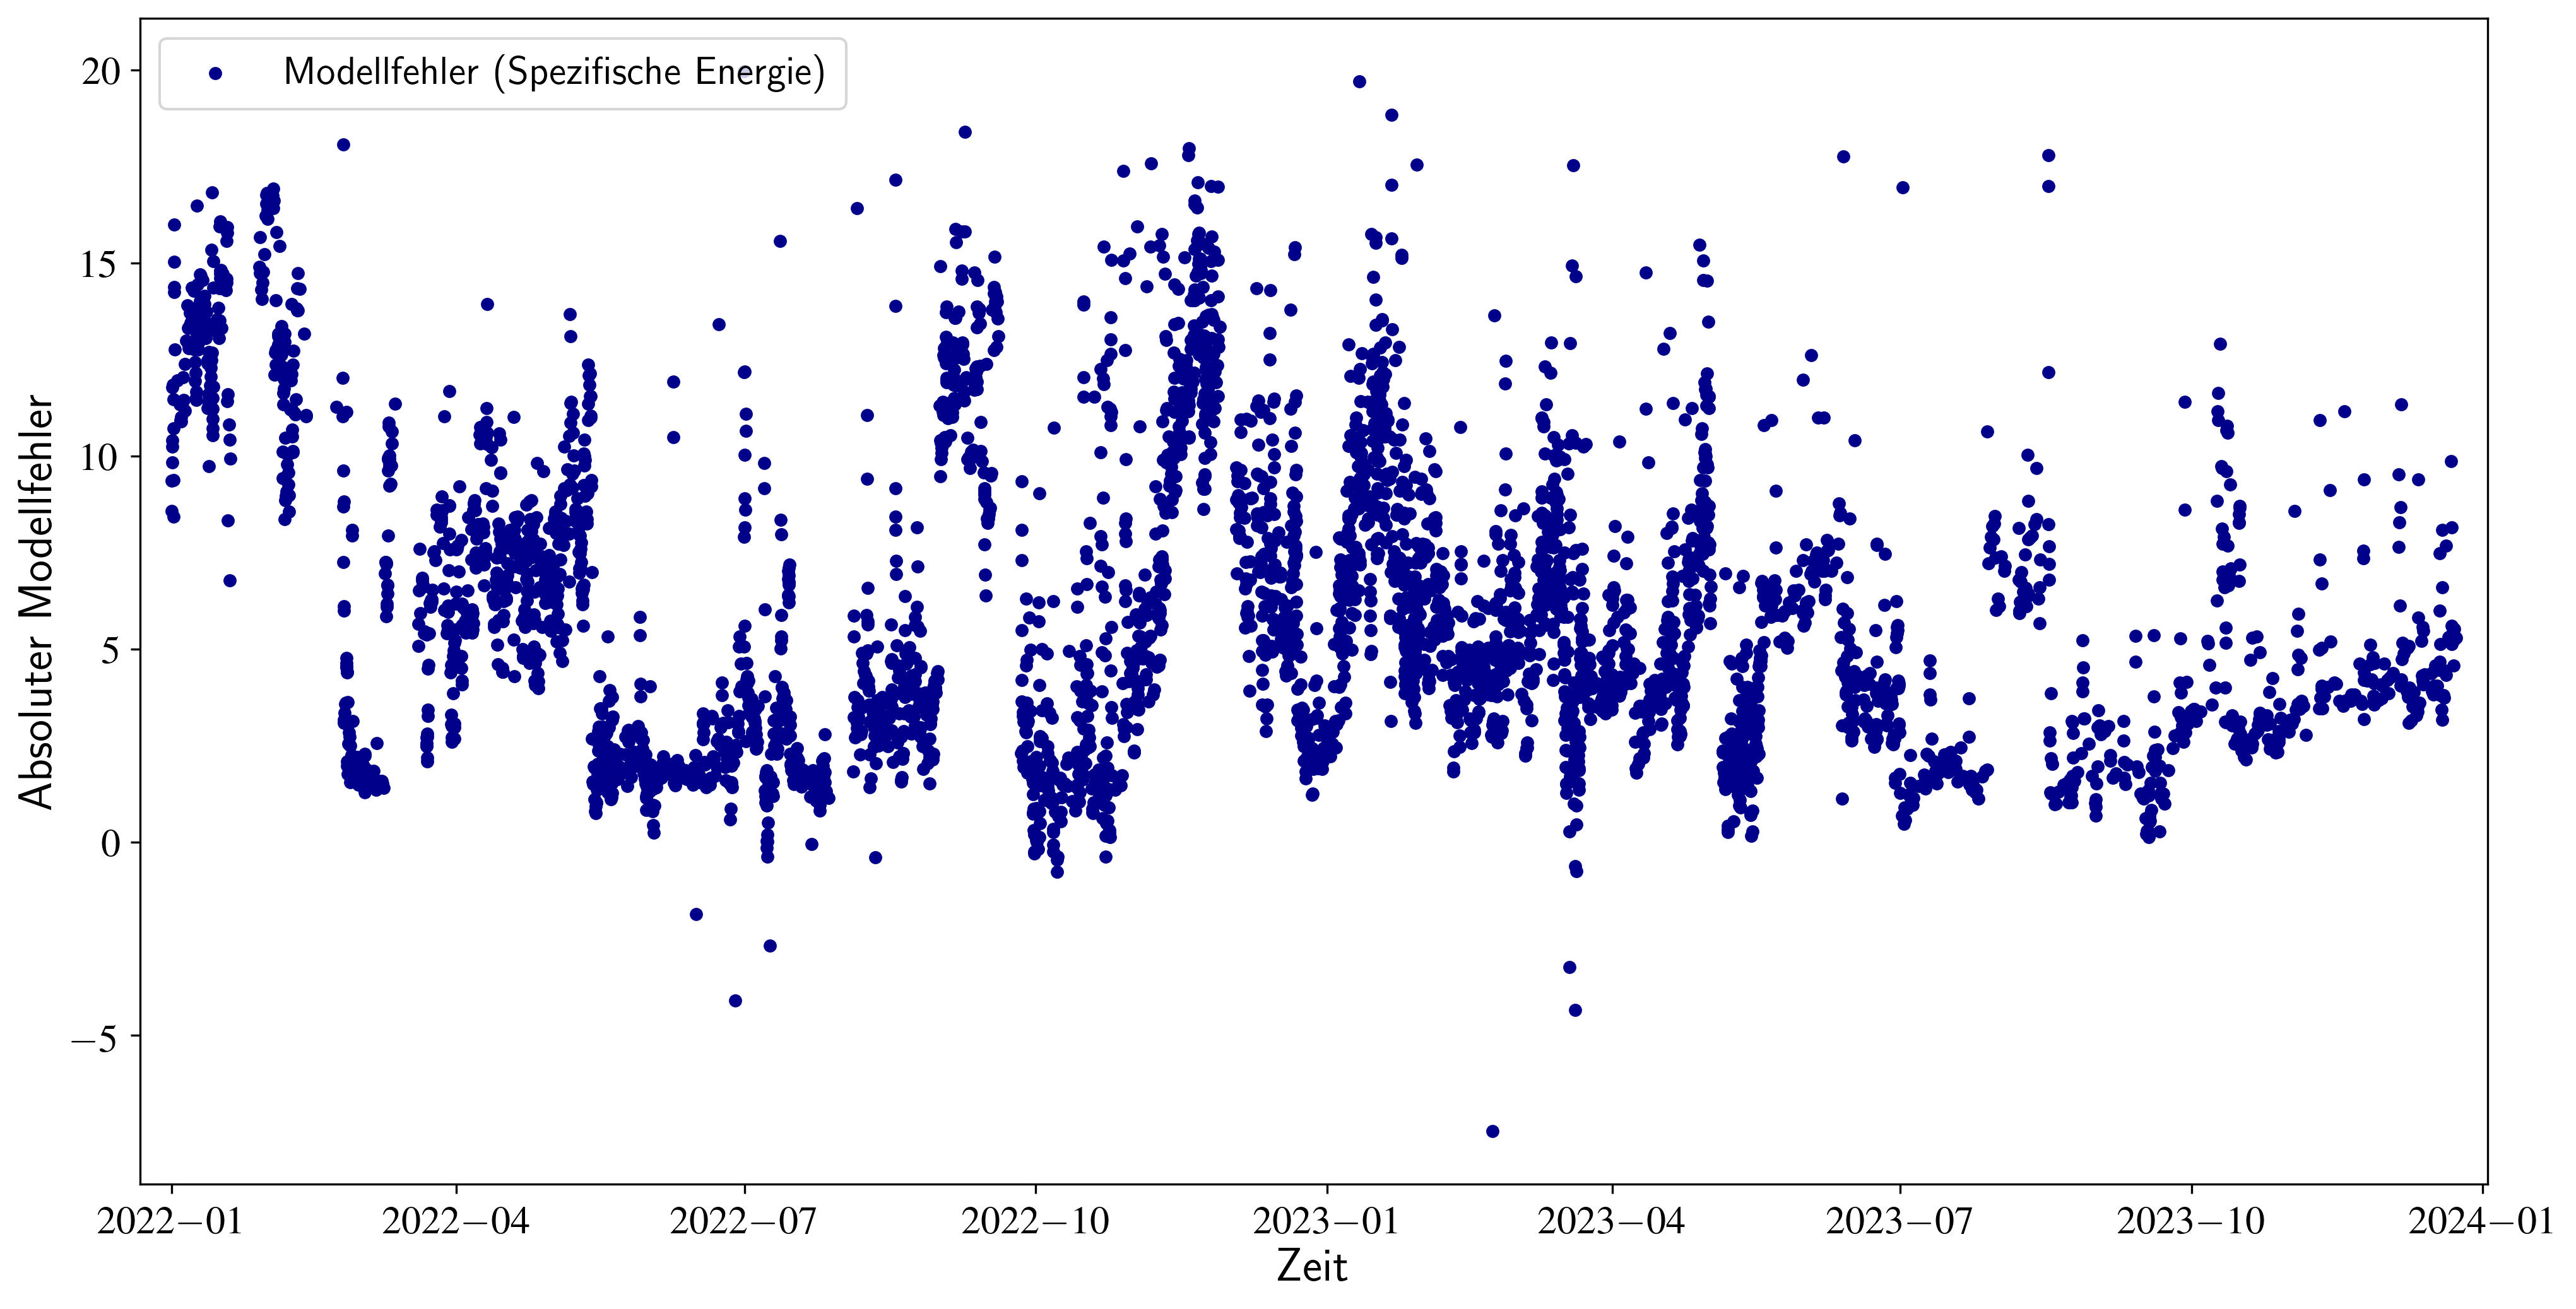

In [60]:
from matplotlib import pyplot as plt
from datetime import timedelta

fig, ax = plt.subplots(figsize=(16, 8))
ax.scatter(prediction_rows['center_time'], prediction_rows['spec_energy_pred_error'], label='Modellfehler (Spezifische Energie)', color='darkblue', marker='o')
ax.set_xlim(data['center_time'].min() - timedelta(days=10), data['center_time'].max() + timedelta(days=10))
ax.set_xlabel('Zeit')
ax.set_ylabel('Absoluter Modellfehler')
ax.legend(['Modellfehler (Spezifische Energie)'], loc='upper left')
plt.show()

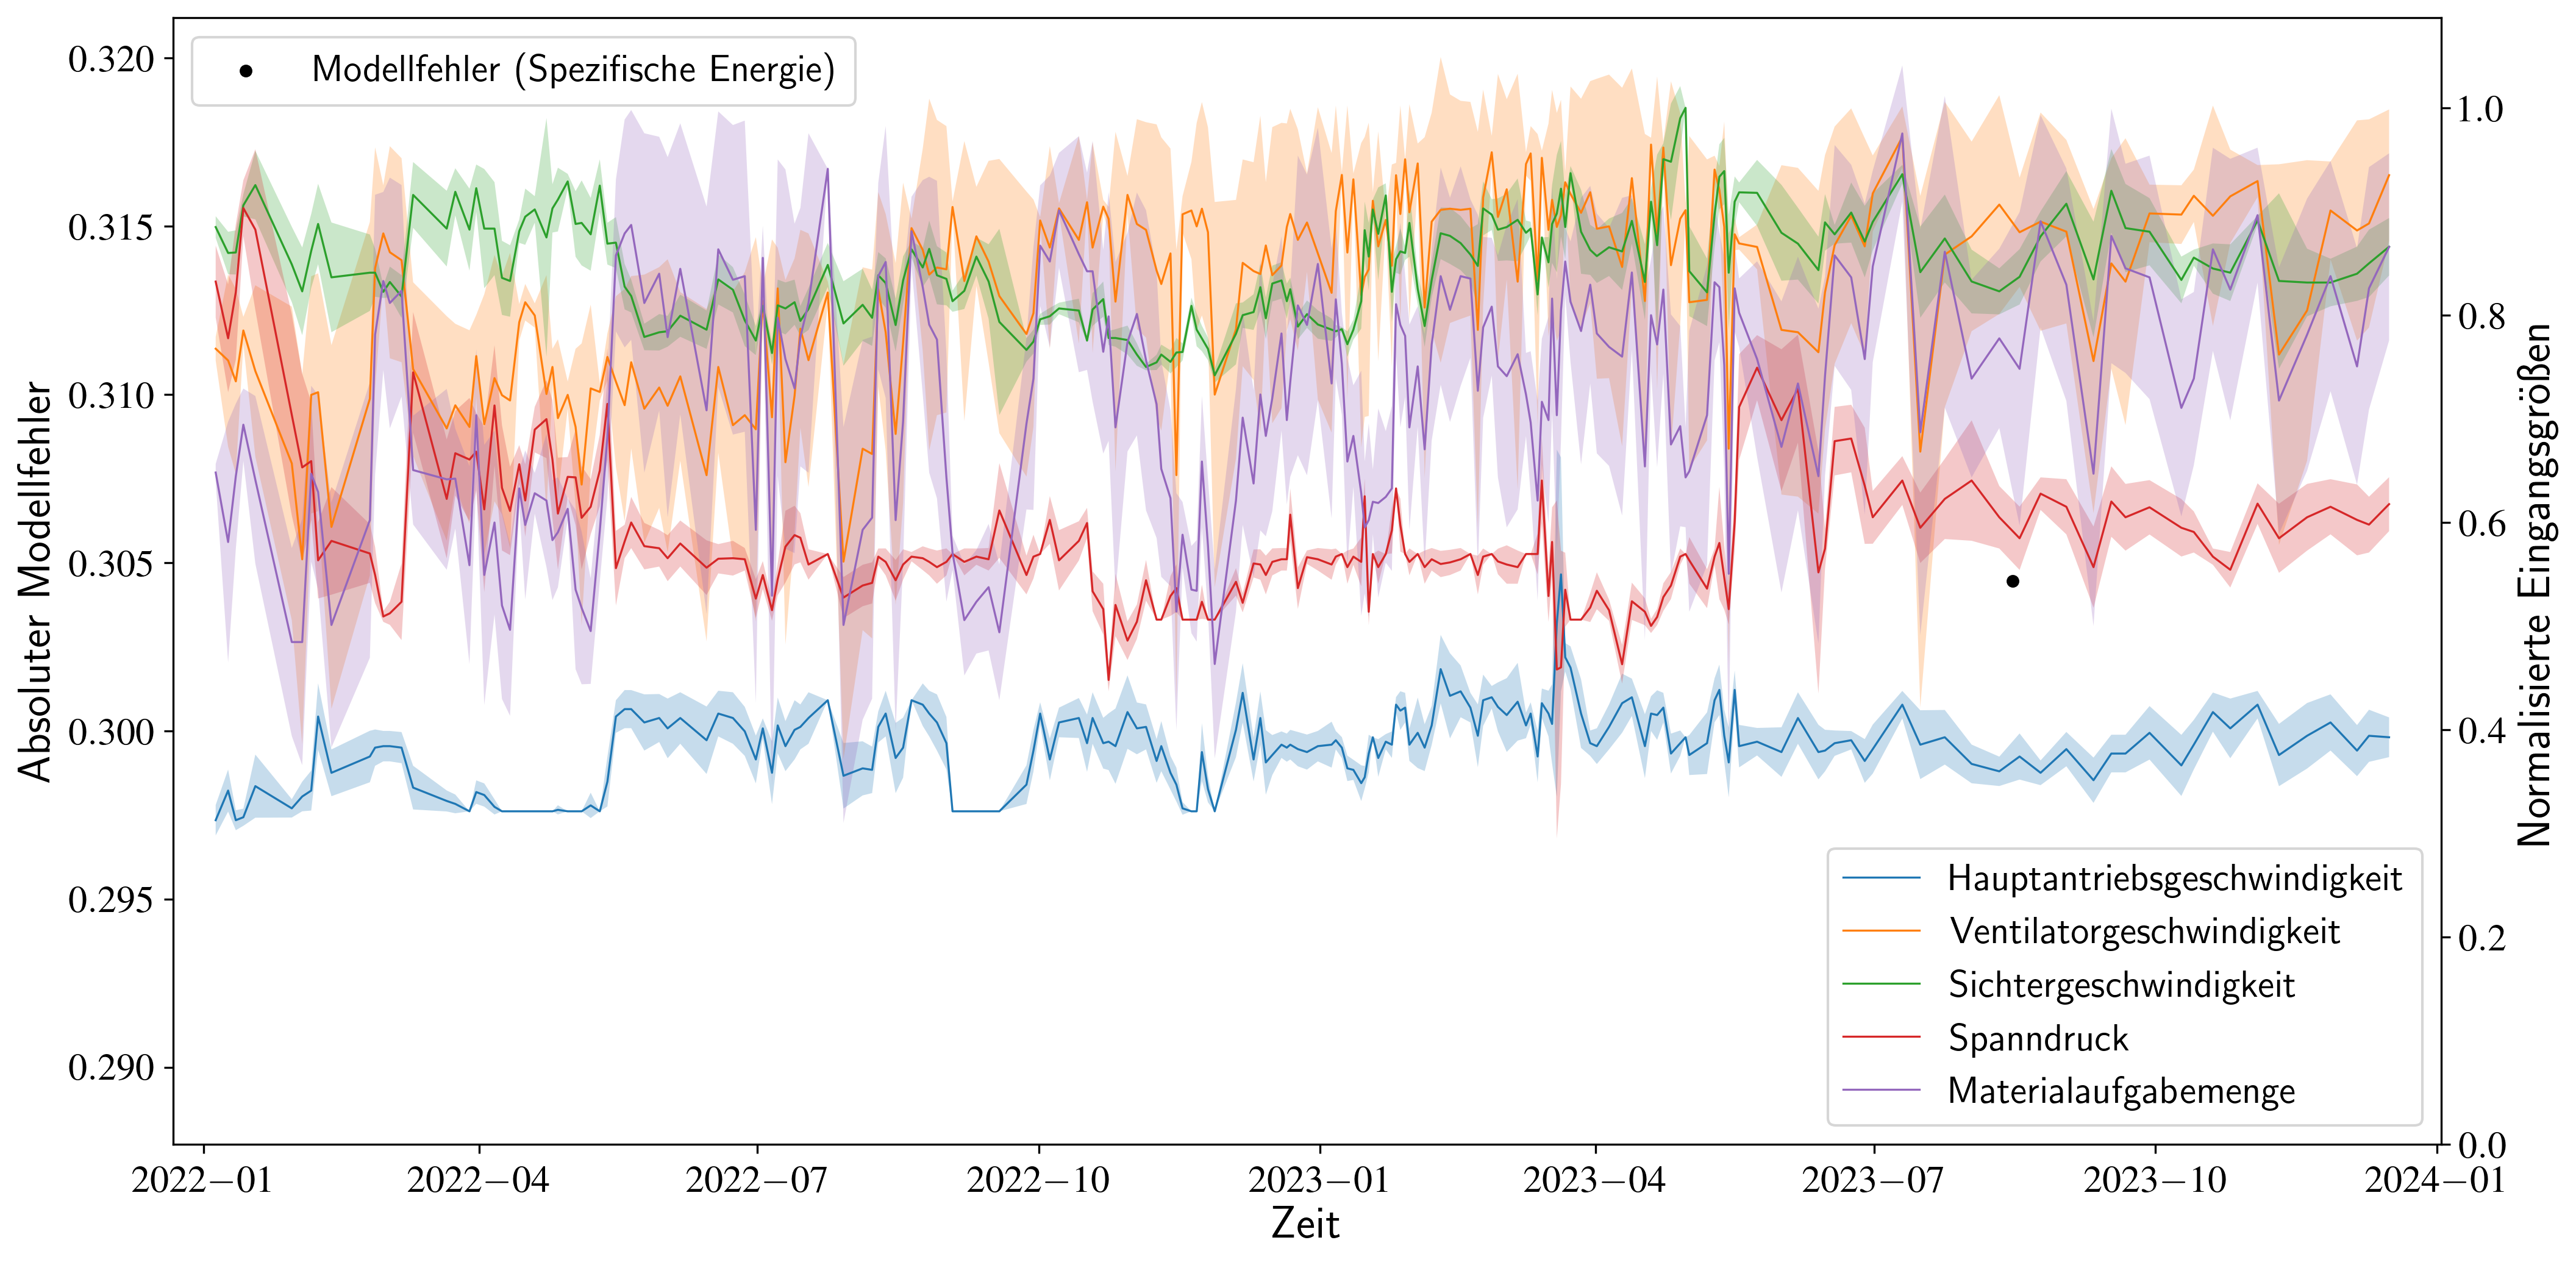

In [54]:
from matplotlib import pyplot as plt
from datetime import timedelta

fig, ax = plt.subplots(figsize=(16, 8))

columns = ['A56-MD01.SC02', 'A56-FN02.SC02', 'A56-SR01.SC02', 'A56-HS01.PS01', 'A51-WF01.FS01']
colmn_names = ['Hauptantriebsgeschwindigkeit', 'Ventilatorgeschwindigkeit', 'Sichtergeschwindigkeit', 'Spanndruck', 'Materialaufgabemenge']

ax.scatter(prediction_rows['center_time'][::8], prediction_rows['spec_energy_pred_error'][::8], label='prediction error', color='black', marker='o')
ax.set_ylabel('Absoluter Modellfehler')

ax2 = ax.twinx()

x = confidence_intervals.index

for column in columns:
    y_mean = confidence_intervals[(column, 'mean')]
    y_ci_lower = confidence_intervals[f'{column}_ci_lower']
    y_ci_upper = confidence_intervals[f'{column}_ci_upper']

    ax2.plot(x, y_mean, label=f'{column}', alpha=1)
    ax2.fill_between(x, y_ci_lower, y_ci_upper, alpha=0.25)

ax2.set_ylim(ymin=0)

ax.set_xlim(data['center_time'].min() - timedelta(days=10), data['center_time'].max() + timedelta(days=10))
ax.set_xlabel('Zeit')
ax2.set_ylabel('Normalisierte Eingangsgrößen')
handles, labels = ax2.get_legend_handles_labels()
ax.legend(['Modellfehler (Spezifische Energie)'], loc='upper left')
ax2.legend(handles[:len(columns)], colmn_names, loc='lower right')
ax.set_zorder(ax2.get_zorder()+1)
ax.set_frame_on(False)
plt.show()

In [55]:
prediction_rows['cluster'] = data.loc[prediction_rows.index, 'cluster']

C:\Users\Pascal Marijan\AppData\Local\Temp\ipykernel_10504\1966436188.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_rows['cluster'] = data.loc[prediction_rows.index, 'cluster']


In [50]:
from datetime import date

roller_maintenance = [date(2022,3,13), date(2022,9,18), date(2022,11,28), date(2023,5,2), date(2023,8,14)]
material_change = date(2023, 3, 17)
calibration_index = data.filter(regex='A[3589]6-HS01.ZO0[1234]', axis=1).sum(axis=1).diff().loc[lambda x: abs(x) >= 2.5]
roller_calibration = data.loc[calibration_index.index, 'center_time']
roller_calibration.loc[0] = pd.Timestamp(0, unit='s')
roller_calibration.sort_index(inplace=True)
roller_calibration = roller_calibration[roller_calibration.diff().dt.days > 0].dropna()

In [49]:
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)  # Reset to default parameters
plt.rcParams.update({
    "text.usetex": True,  # Use LaTeX for text rendering
    "font.family": "serif",  # Use a serif font
    "font.serif": ["Times"],  # Use Times New Roman
    "axes.labelsize": 18,  # Font size for axis labels
    "font.size": 18,  # General font size
    "legend.fontsize": 15,  # Font size for legends
    "xtick.labelsize": 15,  # Font size for x-axis tick labels
    "ytick.labelsize": 15,  # Font size for y-axis tick labels
    "figure.dpi": 300,  # High resolution for publication
    "lines.linewidth": 0.8,  # Line width
    "lines.markersize": 4,  # Marker size
    "savefig.format": "pdf",  # Save figures as PDF
    "savefig.bbox": "tight",  # Adjust bounding box for saving
})

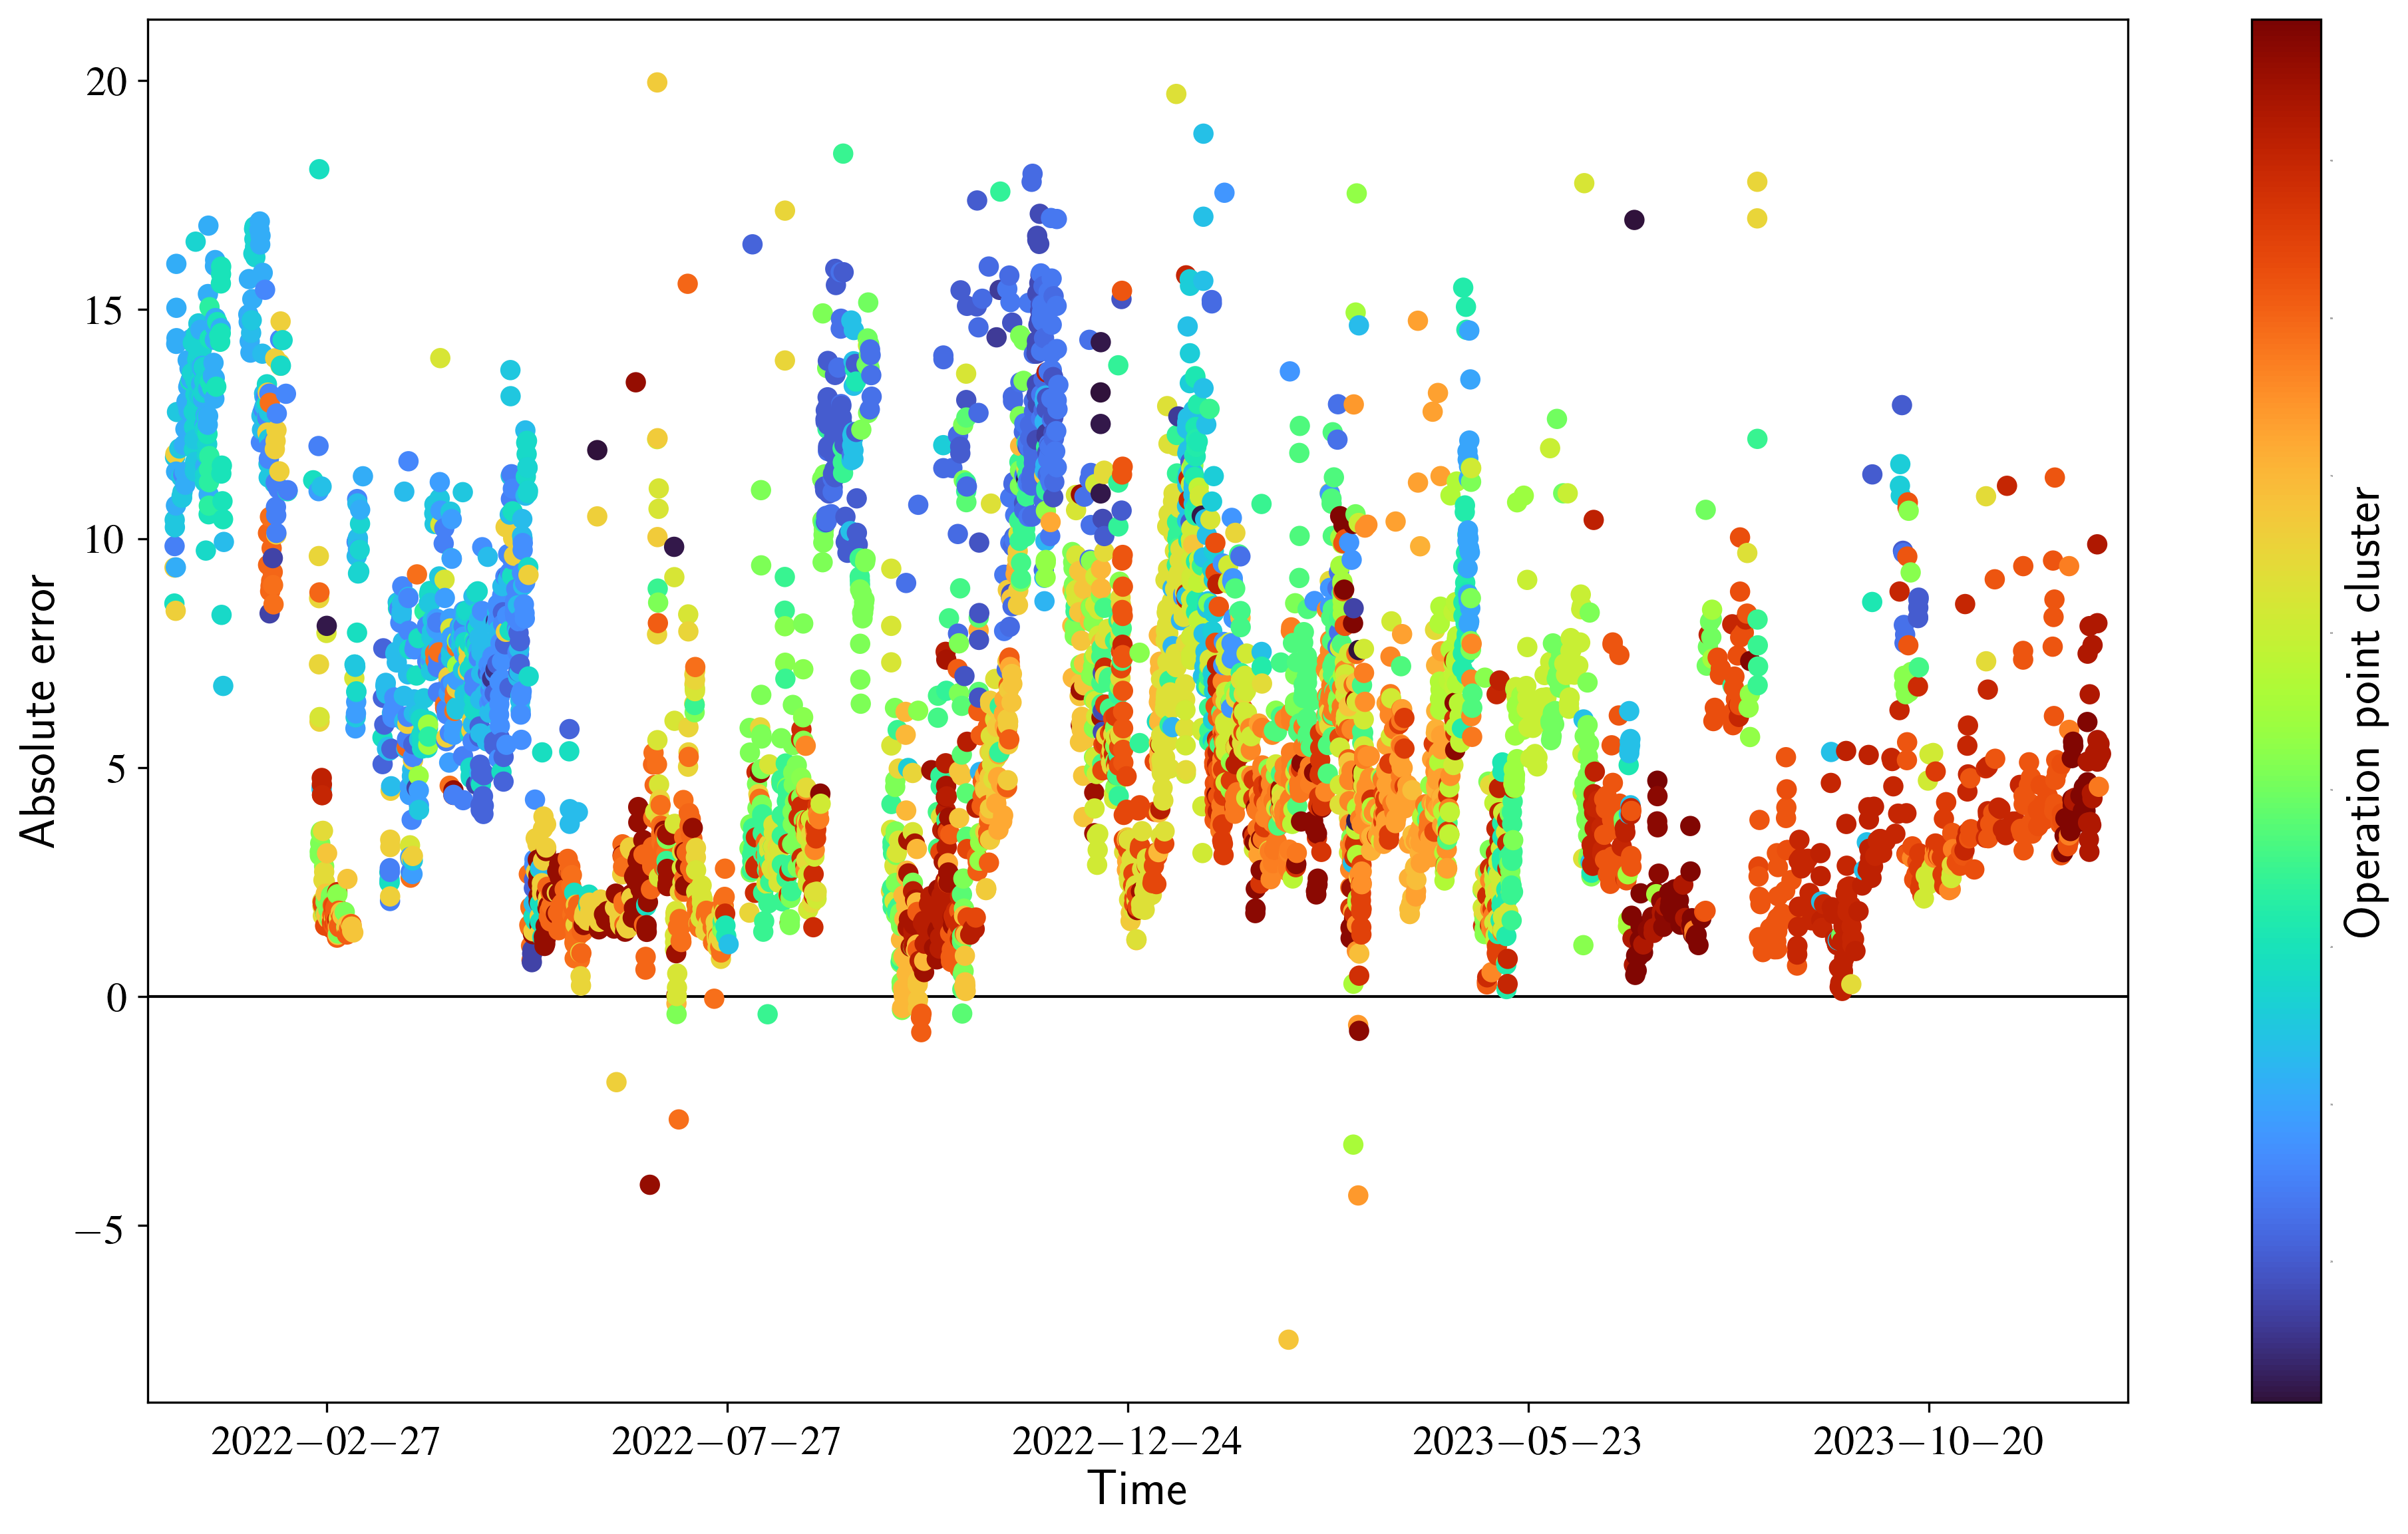

In [61]:
fig, ax = plt.subplots(figsize=(16, 9))
ax.axhline(0, color='black', linestyle='solid', linewidth=1, zorder=0)

scatter = ax.scatter(prediction_rows['center_time'], prediction_rows['spec_energy_pred_error'], c=prediction_rows['cluster'], cmap='turbo', label='Modellfehler (Spezifische Energie)', marker='o', s=40)

# for offset in roller_calibration:
#     ax.axvline(offset, color='0.25', linestyle='solid', linewidth=0.5, label='Walzenkalibrierung')

# for maintenance_date in roller_maintenance:
#     ax.axvline(maintenance_date, color='0.2', linestyle='dashed', linewidth=1, label='Walzenwartung')

# ax.axvline(material_change, color='0', linestyle='dotted', linewidth=1, label='Materialwechsel')

ax.set_xlim(data['center_time'].min() - timedelta(days=10), data['center_time'].max() + timedelta(days=10))
ax.set_xlabel('Time')
ax.set_ylabel('Absolute error')
ax.xaxis.set_major_locator(plt.MaxNLocator(6))  # Reduce the number of ticks on the x-axis

# handles, labels = ax.get_legend_handles_labels()
# by_label = dict(zip(labels, handles))
# by_label['Modellfehler (Spezifische Energie)'] = plt.Line2D([], [], color='black', marker='o', linestyle='None')
# scatter_legend = ax.legend([by_label['Modellfehler (Spezifische Energie)']], ['Modellfehler (Spezifische Energie)'], loc='upper left')

# ax.legend([by_label['Walzenkalibrierung'], by_label['Walzenwartung'], by_label['Materialwechsel']], 
                        #  ['Walzenkalibrierung', 'Walzenwartung', 'Materialwechsel'], loc='lower right')

# ax.add_artist(scatter_legend)

cbar = fig.colorbar(scatter, ax=ax, label='Operation point cluster')
cbar.ax.tick_params(labelsize=0, length=0)
plt.show()

Model adaptation

In [59]:
import keras
from keras import backend

def init_layer(layer):
    weights_shape = layer.get_weights()[0].shape  # kernel weights
    bias_shape = layer.get_weights()[1].shape  # bias weights

    kernel_initializer = keras.initializers.GlorotUniform()
    bias_initializer = keras.initializers.Zeros()

    new_kernel_weights = kernel_initializer(shape=weights_shape)
    new_bias_weights = bias_initializer(shape=bias_shape)

    layer.set_weights([new_kernel_weights, new_bias_weights])

def incremental_training(model, X, y, freeze=[True, True, False], lr=0.0001, reset=True, epochs=1):
    for layer,f in zip(model.layers,freeze):
        if not f and reset:
            init_layer(layer)

    for layer,f in zip(model.layers,freeze):
        layer.trainable = not f

    backend.set_value(model.optimizer.learning_rate, lr)

    if len(X) > 0:
        model.fit(x=X,y=y,epochs=epochs,verbose=0)

    return model

In [60]:
gpac_regex = [gpac for x in preprocessor.features for gpac in x.get_tags()]
data['A56-HS01.PZ14'] = data[['A56-HS01.PZ13', 'A56-HS01.PZ24']].mean(axis=1)
filtered_columns = [col for regex in gpac_regex for col in data.filter(regex=regex, axis=1).columns]
feature_rows = data[filtered_columns]
feature_rows.drop(columns=['A56-HS01.PZ13', 'A56-HS01.PZ24'], inplace=True)

C:\Users\Pascal Marijan\AppData\Local\Temp\ipykernel_10504\1941480418.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  feature_rows.drop(columns=['A56-HS01.PZ13', 'A56-HS01.PZ24'], inplace=True)


In [61]:
for idx, row in data.iterrows():
    X: np.ndarray = np.vstack(feature_rows.loc[[idx]].to_numpy())
    X = preprocessor.scale_features(X)
    y: np.ndarray = model.predict(X)
    y_inverse: np.ndarray = preprocessor.rescale_labels(y)
    data.loc[idx, 'spec_energy_pred_adapt'] = y_inverse[0]
    y_true_norm = preprocessor.scale_labels(np.array([[row['spec_energy']]]))
    model = incremental_training(model, X, y=np.array(y_true_norm))
    y_update = preprocessor.rescale_labels(model.predict(X))[0]
    pass

1/1 [==============================] - 0s 48ms/step


In [62]:
data[['spec_energy', 'spec_energy_pred', 'spec_energy_pred_adapt']]

,spec_energy,spec_energy_pred,spec_energy_pred_adapt
0,112.568978,-0.487738,-0.487738
1,41.510872,-0.028056,-19.064844
2,42.539997,-0.026335,6.610025
3,43.080984,-0.030439,10.096051
4,43.796675,-0.031683,13.946380
...,...,...,...
5051,86.987796,-0.679376,NaN
5052,43.062164,-0.063629,NaN
5053,43.464408,-0.065566,NaN
5054,43.965977,-0.064654,NaN


In [63]:
data['spec_energy_pred_adapt_error'] = data['spec_energy'] - data['spec_energy_pred_adapt']
# prediction_rows = data[(data['spec_energy_pred_error'] <= 7) & (data['spec_energy_pred_error'] > -7) & (data['spec_energy_pred_adapt_error'] <= 7) & (data['spec_energy_pred_adapt_error'] > -7)]

In [64]:
from matplotlib import pyplot as plt
from datetime import timedelta

fig, ax = plt.subplots(figsize=(16, 8))
ax.scatter(prediction_rows['center_time'], prediction_rows['spec_energy_pred_error'], label='Modellfehler gleichbleibendes Modell', color='darkblue', marker='o')
ax.scatter(prediction_rows['center_time'], prediction_rows['spec_energy_pred_adapt_error'], label='Modellfehler angepasstes Modell', color='red', marker='o')
ax.set_xlim(data['center_time'].min() - timedelta(days=10), data['center_time'].max() + timedelta(days=10))
ax.set_xlabel('Zeit')
ax.set_ylabel('Absoluter Modellfehler')
ax.legend(loc='upper left')
plt.show()

KeyError: 'spec_energy_pred_adapt_error'